# Coffee Sales - Data Cleaning Project

Este projeto tem como objetivo realizar a limpeza e preparação de um conjunto de dados de vendas de um loja de café, originalmente contendo valores ausentes, dados inconsistentes e erros de preenchimento.

O objetivo deste notebook é:
- Identificar problemas de qualidades nos dados;
- Padronizar valores inconsistentes;
- Tratar valores ausentes com critérios estatísticos adequados;
- Preparar o dataset para análises futuras e visualização em ferramentas como Power BI.

Importações de bibliotecas

In [ ]:
import pandas as pd
import numpy as np

Leitura dos dados

In [ ]:
df = pd.read_csv('dirty_cafe_sales.csv')

In [ ]:
print(f'Dimensões do dataset: {df.shape}')

Dimensões do dataset: (10000, 8)


Estrutura dos dados

In [ ]:
# Visualização geral do dataset
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
#informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


# Entendendo o dataset

Nesta etapa foi realizada uma análise exploratória inicial para compreender a estrutura das colunas, tipos de dados e identificar possíveis inconsistências ou valores inválidos.




### Transaction ID

In [ ]:
df["Transaction ID"].info()
df["Transaction ID"].head()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Transaction ID
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB


,Transaction ID
0,TXN_1961373
1,TXN_4977031
2,TXN_4271903
3,TXN_7034554
4,TXN_3160411


## Colunas categóricas

In [ ]:
#  Verificando valores da coluna Item
df["Item"].value_counts()

,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344


In [ ]:
# Verificando valores da coluna Payment Metod
df["Payment Method"].value_counts()

,count
Payment Method,
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293


In [ ]:
# Verificando valores da coluna Location
df["Location"].value_counts()

,count
Location,
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


### Colunas numéricas

In [ ]:
# Verificando valores da coluna Quantity
df["Quantity"].value_counts()

,count
Quantity,
5,2013
2,1974
4,1863
3,1849
1,1822
UNKNOWN,171
ERROR,170


In [ ]:
# Verificando valores da coluna Price Per Unit
df["Price Per Unit"].value_counts()

,count
Price Per Unit,
3.0,2429
4.0,2331
2.0,1227
5.0,1204
1.0,1143
1.5,1133
ERROR,190
UNKNOWN,164


In [ ]:
# Verificando valores da coluna Total Spent
df["Total Spent"].value_counts()

,count
Total Spent,
6.0,979
12.0,939
3.0,930
4.0,923
20.0,746
15.0,734
8.0,677
10.0,524
2.0,497


In [ ]:
numeric_columns = ['Quantity', 'Price Per Unit', 'Total Spent']
df[numeric_columns].describe()


,Quantity,Price Per Unit,Total Spent
count,9862,9821,9827
unique,7,8,19
top,5,3.0,6.0
freq,2013,2429,979


### Transaction Date

In [ ]:
# Verificando valores da coluna Transaction Date
df["Transaction Date"].value_counts(dropna=False).head(10)

,count
Transaction Date,
UNKNOWN,159
NaN,159
ERROR,142
2023-06-16,40
2023-02-06,40
2023-09-21,39
2023-07-21,39
2023-07-24,39
2023-03-13,39


### Verificação de valores ausentes

Antes de qualquer tratamento, foi realizada a verificação da existência de valores ausentes no dataset.


In [ ]:
df.isna().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


## Tratamento de valores inválidos por tipo de dado

Os valores "UNKNOWN" e "ERROR" foram tratados de forma diferente
dependendo do tipo da coluna, visando preservar a coerência dos dados
e permitir análises futuras adequadas.

### Colunas categóricas

Para as colunas categóricas, os valores inválidos foram substituídos por
categorias explícitas indicando ausência de informação.

In [ ]:
df['Item'] = df['Item'].replace(['UNKNOWN', 'ERROR'], 'Missing Item')
df['Payment Method'] = df['Payment Method'].replace(['UNKNOWN', 'ERROR'], 'Missing Payment Method')
df['Location'] = df['Location'].replace(['UNKNOWN', 'ERROR'], 'Missing Location')

display(df['Item'].value_counts(dropna=False))
display(df['Payment Method'].value_counts(dropna=False))
display(df['Location'].value_counts(dropna=False))

,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
Missing Item,636


,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
Missing Payment Method,599


,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
Missing Location,696


### Colunas numéricas

Nas colunas numéricas, os valores inválidos foram convertidos para NaN
a fim de permitir a conversão correta do tipo de dado e posterior
tratamento estatístico.


In [ ]:
numeric_columns = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in numeric_columns:
    df[col] = df[col].replace(['UNKNOWN', 'ERROR'], np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
display(df['Quantity'].value_counts(dropna=False))
display(df['Price Per Unit'].value_counts(dropna=False))
display(df['Total Spent'].value_counts(dropna=False))

,count
Quantity,
5.0,2013
2.0,1974
4.0,1863
3.0,1849
1.0,1822
NaN,479


,count
Price Per Unit,
3.0,2429
4.0,2331
2.0,1227
5.0,1204
1.0,1143
1.5,1133
NaN,533


,count
Total Spent,
6.0,979
12.0,939
3.0,930
4.0,923
20.0,746
15.0,734
8.0,677
10.0,524
NaN,502


### Coluna de data (Transaction Date)

Os valores inválidos ("UNKNOWN" e "ERROR") foram inicialmente substituídos
por um marcador de ausência ("Missing Date") para padronização visual.
Em seguida, a coluna foi convertida para o tipo datetime.

Durante a conversão, valores inválidos foram automaticamente transformados
em NaT, garantindo a consistência do tipo de dado.

In [ ]:
df['Transaction Date'] = df['Transaction Date'].replace(['UNKNOWN', 'ERROR'], 'Missing Date')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
display(df['Transaction Date'].value_counts(dropna=False))

,count
Transaction Date,
NaT,460
2023-06-16,40
2023-02-06,40
2023-09-21,39
2023-07-21,39
...,...
2023-11-24,15
2023-04-27,15
2023-07-22,14


In [ ]:
df["Transaction Date"].value_counts(dropna=False)

,count
Transaction Date,
NaT,460
2023-06-16,40
2023-02-06,40
2023-09-21,39
2023-07-21,39
...,...
2023-11-24,15
2023-04-27,15
2023-07-22,14


## Tratamento de valores ausentes

### Colunas numéricas

Os valores ausentes nas colunas numéricas foram substituídos pela mediana, por ser uma medida estatística mais robusta à presença de outliers.

In [ ]:
# Substituir valores ausentes (NaN) na coluna 'Quantity' pela mediana
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

# Substituir valores ausentes (NaN) na coluna 'Price Per Unit' pela mediana
df['Price Per Unit'].fillna(df['Price Per Unit'].median(), inplace=True)

# Substituir valores ausentes (NaN) na coluna 'Total Spent' pela mediana
df['Total Spent'].fillna(df['Total Spent'].median(), inplace=True)

# Verificar a quantidade de valores ausentes em cada coluna
display(df.isna().sum())

/tmp/ipython-input-3929626050.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
/tmp/ipython-input-3929626050.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,0
Transaction ID,0
Item,333
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,2579
Location,3265
Transaction Date,460


### Colunas categóricas

Os valores ausentes nas colunas categóricas foram tratados utilizando
a moda, garantindo a preservação das categorias mais frequentes.

In [ ]:
# Substituir valores ausentes (NaN) na coluna 'Item' pela moda
df['Item'].fillna(df['Item'].mode()[0], inplace=True)

# Substituir valores ausentes (NaN) na coluna 'Payment Method' pela moda
df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)

# Substituir valores ausentes (NaN) na coluna 'Location' pela moda
df['Location'].fillna(df['Location'].mode()[0], inplace=True)

# Verificar se ainda existem valores ausentes no dataset
display(df.isna().sum())

/tmp/ipython-input-3355735444.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item'].fillna(df['Item'].mode()[0], inplace=True)
/tmp/ipython-input-3355735444.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,460


### Remoção de registros com data inválida

Após a conversão da coluna de data para o formato `datetime`, alguns registros
apresentaram valores ausentes (`NaT`). Como a data da transação é essencial
para análises temporais e agregações ao longo do tempo, esses registros foram
removidos do dataset.

Essa decisão garante a consistência dos dados e evita distorções em análises
baseadas em período.

In [ ]:
# Remover registros com data de transação inválida (NaT), pois a ausência de data compromete análises temporais
df.dropna(subset=['Transaction Date'], inplace=True)

# Verificar a quantidade de valores ausentes após a remoção
display(df.isna().sum())

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


A coluna location indica se a venda foi realizada no estabelecimento físico ou para retirada.
Para melhorar a clareza semântica do dataset, a coluna foi renomeada para order_type, refletindo melhor seu papel analítico.

In [ ]:
df.rename(columns={'order_type': 'Order Type'}, inplace=True)
display(df.head())
display(df.columns)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Order Type,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Missing Payment Method,Missing Location,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Order Type', 'Transaction Date'],
      dtype='object')

## Validação final dos dados

Após a conclusão do processo de limpeza e tratamento, foi realizada uma
validação final para garantir a consistência do dataset e a adequação
para análises futuras.

In [ ]:
# Verificar estrutura final do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   object        
 1   Item              9540 non-null   object        
 2   Quantity          9540 non-null   float64       
 3   Price Per Unit    9540 non-null   float64       
 4   Total Spent       9540 non-null   float64       
 5   Payment Method    9540 non-null   object        
 6   Order Type        9540 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 670.8+ KB


In [ ]:
# Visualizar amostra dos dados tratados
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Order Type,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Missing Payment Method,Missing Location,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
# Estatísticas descritivas das colunas numéricas
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9540.000000,9540.000000,9540.000000,9540
mean,3.024109,2.952673,8.868816,2023-07-01 23:00:31.698113536
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.384186,1.243449,5.861817,NaN


## Exportação do dataset limpo

Após o processo de limpeza, o dataset foi exportado para uso em análises
exploratórias, visualizações e ferramentas de Business Intelligence.

In [ ]:
df.to_csv('clean_cafe_sales.csv', index=False)

## Próximos passos

Com o dataset limpo e estruturado, as próximas etapas possíveis incluem:

- Análise exploratória de dados (EDA)
- Criação de dashboards no Power BI
- Análises temporais de vendas
- Identificação de padrões de consumo por produto, local e método de pagamento

# Análise Exploratória de Dados (EDA)

Nesta etapa, o objetivo é explorar o comportamento das vendas a partir
do dataset já limpo, buscando identificar padrões, tendências e insights
iniciais.

### Visão geral das vendas

Qual é o valor típico gasto por transação?

In [ ]:
df["Total Spent"].describe()

,Total Spent
count,9540.000000
mean,8.868816
std,5.861817
min,1.000000
25%,4.000000
50%,8.000000
75%,12.000000
max,25.000000


### Produtos mais vendidos

Quais itens são mais vendidos?

In [ ]:
itens_sales = df["Item"].value_counts()
itens_sales

,count
Item,
Juice,1439
Coffee,1123
Salad,1099
Cake,1082
Sandwich,1075
Smoothie,1048
Cookie,1035
Tea,1027
Missing Item,612


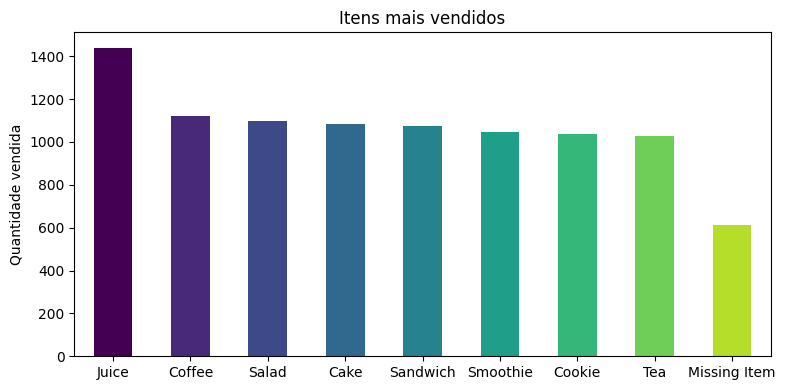

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(8, 4))

num_colors = len(itens_sales)
colors = [cm.viridis(i/float(num_colors)) for i in range(num_colors)]

itens_sales.plot(kind="bar", title="Itens mais vendidos", xlabel="", rot=0, color=colors)
plt.ylabel('Quantidade vendida')
plt.tight_layout() # Ajusta o layout para evitar cortes de rótulos
plt.show()

**Insight:** *Juice* é o item mais vendido, seguido por *Coffee* e *Salad*, indicando uma preferência por bebidas e opções rápidas. Além disso, a presença relevante de *Missing Item* sugere problemas no registro dos produtos, o que pode impactar análises mais detalhadas de performance por item.



### Receita por produto

Quais itens geram mais receita?

In [ ]:
revenue_by_item = (df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False))
revenue_by_item


,Total Spent
Item,
Salad,16263.0
Sandwich,12824.0
Juice,12788.0
Smoothie,12576.0
Cake,9777.0
Coffee,6922.0
Missing Item,5299.0
Tea,4813.5
Cookie,3346.0


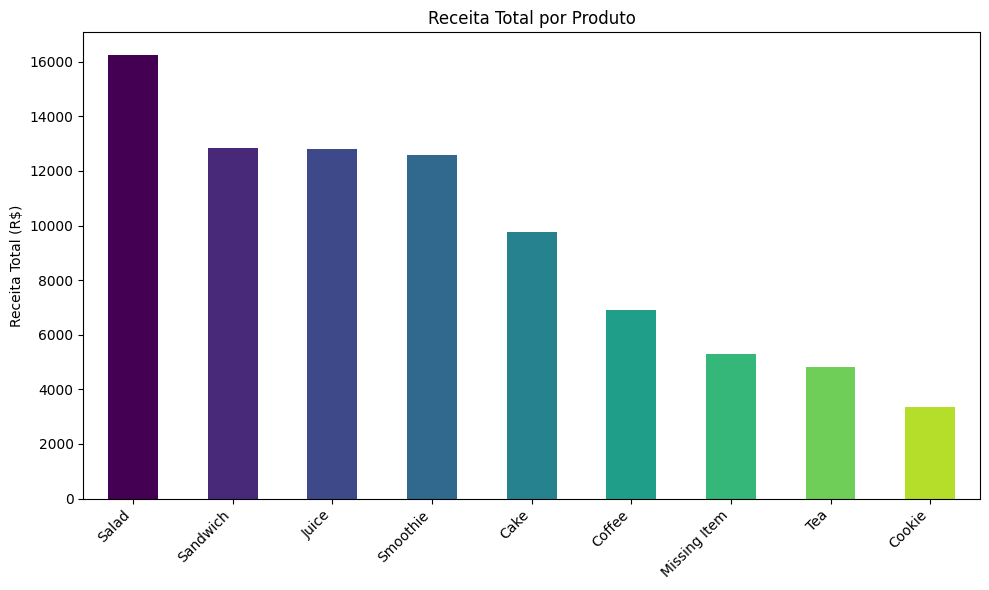

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(10, 6))

num_colors = len(revenue_by_item)
colors = [cm.viridis(i/float(num_colors)) for i in range(num_colors)]

revenue_by_item.plot(kind='bar', color=colors)
plt.title('Receita Total por Produto')
plt.ylabel('Receita Total (R$)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** Apesar de não ser o item mais vendido em quantidade, *Salad* lidera o faturamento total, indicando um ticket médio mais elevado em comparação com bebidas como *Juice* e *Coffee*. Isso sugere que itens alimentícios podem ter maior impacto na receita do que no volume de vendas.


### Métodos de pagamento

Qual método de pagamento é o mais utilizado?

In [ ]:
payment_distribution = df['Payment Method'].value_counts(normalize=True)*100
payment_distribution

,proportion
Payment Method,
Digital Wallet,48.595388
Credit Card,22.746331
Cash,22.620545
Missing Payment Method,6.037736


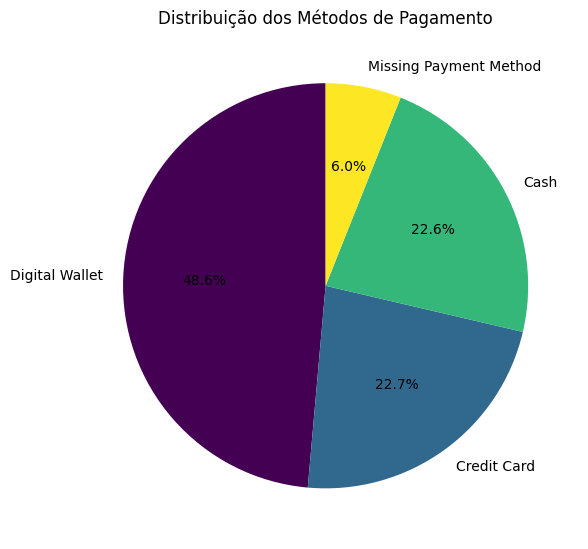

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
payment_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribuição dos Métodos de Pagamento')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insight:** A maioria das transações é realizada via *Digital Wallet*, representando quase metade dos pagamentos, o que indica uma forte adesão a métodos digitais. No entanto, *Credit Card* e *Cash* ainda mantêm participações semelhantes, sugerindo a necessidade de oferecer múltiplas opções de pagamento.

### Vendas por tipo de atendimento

As vendas são realizadas com maior frequência em loja (*in-store*) ou para
retirada (*takeaway*)?

In [ ]:
sales_by_order_type = df['Order Type'].value_counts()
sales_by_order_type

,count
Order Type,
Takeaway,6007
In-store,2872
Missing Location,661


**Insight:** A maior parte dos pedidos ocorre no formato *Takeaway*, indicando uma preferência dos clientes por conveniência e consumo fora do estabelecimento. Ainda assim, o volume de *In-store* permanece relevante, sugerindo que ambos os canais desempenham papéis importantes nas vendas.

## Conclusões da Análise Exploratória

A análise revelou que o consumo é majoritariamente orientado à conveniência, com
predominância de pedidos *takeaway* e uso elevado de métodos de pagamento digitais.
Embora bebidas liderem em volume de vendas, itens alimentícios apresentam maior
contribuição para a receita total.

Além disso, foram identificadas inconsistências no registro de dados, como itens e
métodos de pagamento ausentes, destacando oportunidades de melhoria na coleta de dados.